## missing values

un caso muy comun es que en un dataset no se tenga valores en ciertos datos, puede pasar que no este, se perdio, etc
hay distintas tecnicas para trabajar con este tipo de datos "missing"

In [28]:
import pandas as pd
import numpy as np
import matplotlib


In [16]:
ruta = "/home/balthazar/Escritorio/progra/Analisis-de-datos/teoria/modulo 4/csv/titanic.csv"
data = pd.read_csv(ruta)
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


para representar missing values en pandas usamos el valor __"np.nan"__, otro valor que se usa es np.inf (pero para numeros infinito no para missing values), el otro que se usa para representar missing values es el __" none "__

In [9]:
df = pd.DataFrame({"A": [1,2,3,4], "B": [8,2,np.nan,5]})
df

,A,B
0,1,8.0
1,2,2.0
2,3,NaN
3,4,5.0


A su vez, las funciones de agregación también
permiten controlar cómo se trata NaN.
Por defecto son ignorados, pero se puede controlar
con el parámetro skipna.

In [11]:
df.mean(skipna=False)

A    2.5
B    NaN
dtype: float64

In [12]:
df.mean()

A    2.5
B    5.0
dtype: float64

## isna

isna  se utiliza para detectar missing values, este metodo mapea los datos del dataframe o series boolenos


In [13]:
df.isna()

,A,B
0,False,False
1,False,False
2,False,True
3,False,False


tmb existe su contraparte __notna__

In [15]:
df.notna() # vemos que la columan B , tiene en la fila 2 un NAN


,A,B
0,True,True
1,True,True
2,True,False
3,True,True


In [17]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## dropna
una forma de tratar a los nan, es simplemente descartarlos
el metodo dropna elimina las filas que contengan __al menos 1 dato nan__ 
se puede limitar las columnas a considerar con el parametro __subset__ o eliminar las finlas con todas las columnas nan con __how__ 


In [19]:
data.dropna().info()

<class 'pandas.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    str    
 4   Sex          183 non-null    str    
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    str    
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    str    
 11  Embarked     183 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 18.6 KB


## fillna
para no perder infromacion tambien se puede usar __fillna__ para poder rellenar esos valores NaN

In [ ]:
data["Age"].fillna(data["Age"].mean())

np.float64(29.69911764705882)

## interpolate
cuando tengamos datos ordenados se pueden interpolar los datos faltantes con el metodo __interpolate__ 

<Axes: >

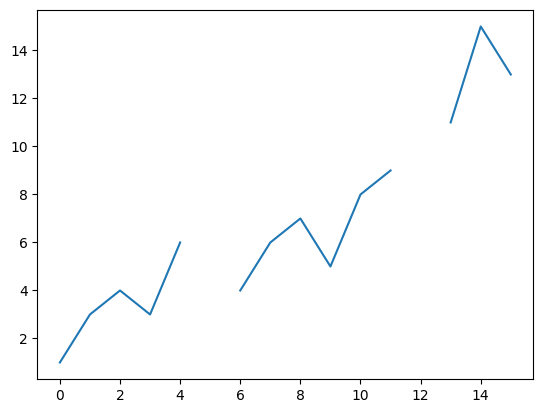

In [29]:
s = pd.Series([1,3,4,3,6,np.nan,4,6,7,5,8,9,np.nan,11,15,13])
s.plot()

<Axes: >

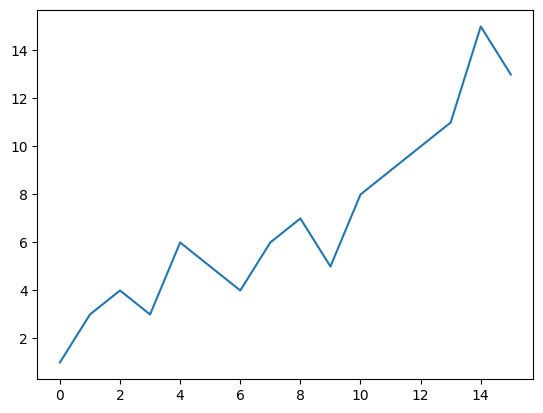

In [30]:
s.interpolate().plot()